# Data Exploratory 

In [2]:
import pandas as pd

In [8]:
df = pd.read_csv("dataset_mood_smartphone.csv", sep=",")
df.head()

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [16]:
df

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


Note:

Some rows in unnamed is removed! 

## Data Summary

In [22]:
# The amount of data points
len(df)

376912

In [29]:
missing_per_column = df.isna().sum()
print(missing_per_column)

Unnamed: 0      0
id              0
time            0
variable        0
value         202
dtype: int64


In [39]:
df.dtypes

Unnamed: 0             int64
id                    object
time          datetime64[ns]
variable              object
value                float64
dtype: object

In [40]:
df['time']=pd.to_datetime(df['time'])
df

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


### Variable feature

In [18]:
df['variable'].value_counts()

variable
screen                  96578
appCat.builtin          91288
appCat.communication    74276
appCat.entertainment    27125
activity                22965
appCat.social           19145
appCat.other             7650
circumplex.valence       5643
circumplex.arousal       5643
appCat.office            5642
mood                     5641
call                     5239
appCat.travel            2846
appCat.utilities         2487
sms                      1798
appCat.finance            939
appCat.unknown            939
appCat.game               813
appCat.weather            255
Name: count, dtype: int64

In [25]:
df['variable'].nunique()

19

### Investigate where the missing value is 

In [41]:
from pathlib import Path

In [68]:
output_dir = Path("plots_by_id_variable")
output_dir.mkdir(exist_ok=True)

In [43]:
df = df.sort_values(["id", "variable", "time"])

In [44]:
df

,Unnamed: 0,id,time,variable,value
16927,16928,AS14.01,2014-03-20 22:00:00.000,activity,0.071429
16928,16929,AS14.01,2014-03-20 23:00:00.000,activity,0.091667
16929,16930,AS14.01,2014-03-21 00:00:00.000,activity,0.008333
16930,16931,AS14.01,2014-03-21 01:00:00.000,activity,0.000000
16931,16932,AS14.01,2014-03-21 02:00:00.000,activity,0.000000
...,...,...,...,...,...
143502,143503,AS14.33,2014-05-26 14:42:25.733,sms,1.000000
143503,143504,AS14.33,2014-05-27 10:52:19.687,sms,1.000000
143504,143505,AS14.33,2014-05-27 10:56:27.632,sms,1.000000
143505,143506,AS14.33,2014-05-28 19:21:19.711,sms,1.000000


time
2014-03-20 22:00:00    0.071429
2014-03-20 23:00:00    0.091667
2014-03-21 00:00:00    0.008333
2014-03-21 01:00:00    0.000000
2014-03-21 02:00:00    0.000000
                         ...   
2014-05-05 06:00:00    0.000000
2014-05-05 07:00:00    0.000000
2014-05-05 08:00:00    0.000000
2014-05-05 09:00:00    0.010638
2014-05-05 10:00:00    0.000000
Name: value, Length: 1056, dtype: float64
h
2014-03-20 22:00:00    0.071429
2014-03-20 23:00:00    0.091667
2014-03-21 00:00:00    0.008333
2014-03-21 01:00:00    0.000000
2014-03-21 02:00:00    0.000000
                         ...   
2014-05-05 06:00:00    0.000000
2014-05-05 07:00:00    0.000000
2014-05-05 08:00:00    0.000000
2014-05-05 09:00:00    0.010638
2014-05-05 10:00:00    0.000000
Freq: h, Name: value, Length: 1093, dtype: float64


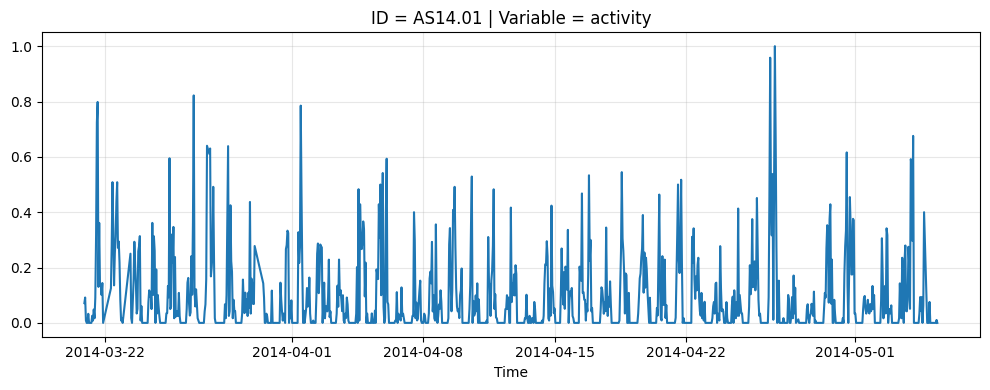

time
2014-03-20 22:25:56.111     2.288
2014-03-20 22:34:51.135     1.007
2014-03-20 22:48:30.211    37.125
2014-03-20 22:49:37.628     1.003
2014-03-20 22:50:40.273     4.017
                            ...  
2014-05-05 09:41:34.470     6.203
2014-05-05 09:41:40.795     3.423
2014-05-05 09:41:44.243     1.047
2014-05-05 09:41:45.292    12.049
2014-05-05 09:41:57.378     3.033
Name: value, Length: 6299, dtype: float64
h
2014-03-20 22:25:56.111    2.288
2014-03-20 23:25:56.111      NaN
2014-03-21 00:25:56.111      NaN
2014-03-21 01:25:56.111      NaN
2014-03-21 02:25:56.111      NaN
                           ...  
2014-05-05 05:25:56.111      NaN
2014-05-05 06:25:56.111      NaN
2014-05-05 07:25:56.111      NaN
2014-05-05 08:25:56.111      NaN
2014-05-05 09:25:56.111      NaN
Freq: h, Name: value, Length: 1092, dtype: float64


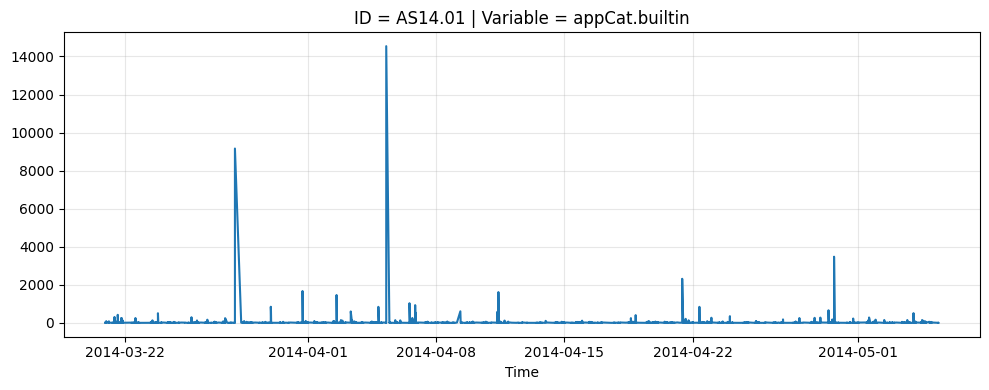

time
2014-03-20 22:25:58.417      4.190
2014-03-20 22:34:48.921      2.009
2014-03-20 22:49:07.341     30.286
2014-03-20 22:50:44.292     16.054
2014-03-20 22:53:03.756     13.053
                            ...   
2014-05-05 00:30:35.262    260.162
2014-05-05 00:36:00.686     34.139
2014-05-05 00:37:02.137     15.068
2014-05-05 00:37:19.221     32.182
2014-05-05 09:41:07.858     26.476
Name: value, Length: 5337, dtype: float64
h
2014-03-20 22:25:58.417    4.19
2014-03-20 23:25:58.417     NaN
2014-03-21 00:25:58.417     NaN
2014-03-21 01:25:58.417     NaN
2014-03-21 02:25:58.417     NaN
                           ... 
2014-05-05 05:25:58.417     NaN
2014-05-05 06:25:58.417     NaN
2014-05-05 07:25:58.417     NaN
2014-05-05 08:25:58.417     NaN
2014-05-05 09:25:58.417     NaN
Freq: h, Name: value, Length: 1092, dtype: float64


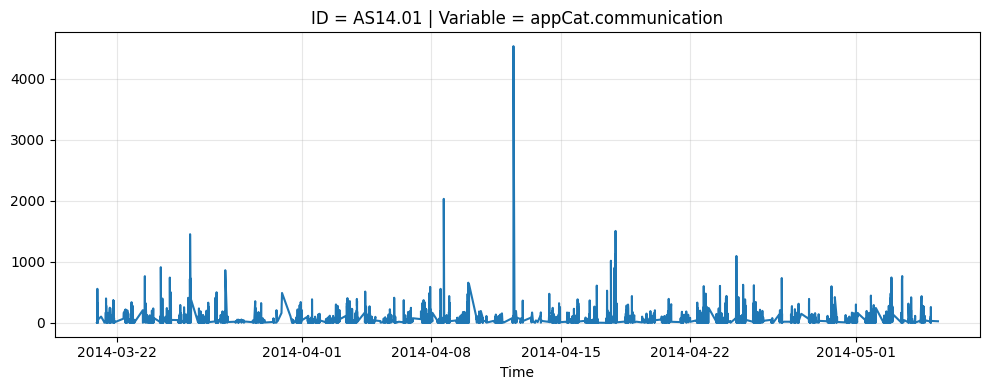

Plots saved in: /Users/ameetran/DataMining/plots_by_id_variable


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt



# ----------------------------
# 3. Function to infer frequency
# ----------------------------
def infer_group_frequency(times):
    """
    Try to infer a sensible frequency from observed timestamps.
    Falls back to daily if it cannot be inferred.
    """
    if len(times) < 3:
        return "D"

    inferred = pd.infer_freq(times.sort_values())
    if inferred is not None:
        return inferred

    # fallback based on median difference
    diffs = times.sort_values().diff().dropna()
    if len(diffs) == 0:
        return "D"

    median_diff = diffs.median()

    if median_diff <= pd.Timedelta(minutes=1):
        return "min"   # minute
    elif median_diff <= pd.Timedelta(hours=1):
        return "h"   # hourly
    elif median_diff <= pd.Timedelta(days=1):
        return "D"   # daily
    elif median_diff <= pd.Timedelta(days=7):
        return "D"
    else:
        return "D"

# ----------------------------
# 4. Plot each id-variable pair
# ----------------------------

for (person_id, var_name), group in df.groupby(["id", "variable"]):
    if group.empty:
        continue

    group = group.sort_values("time")


    # If there are repeated timestamps, average them
    series = group.groupby("time")["value"].mean()
    print(series)

    # Build a complete time index so missing timestamps become NaN
    freq = infer_group_frequency(series.index.to_series())
    print(freq)
    full_index = pd.date_range(
        start=series.index.min(),
        end=series.index.max(),
        freq=freq
    )

    series_full = series.reindex(full_index)
    print(series_full)

    # check whether this group contains missing values
    has_missing = series.isna().any()
    amount_missing = series.isna().sum()

    # build title
    title = f"ID = {person_id} | Variable = {var_name}"
    if has_missing:
        title +=  f" | missing {amount_missing}"

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values)
    plt.title(f"{title}")
    plt.xlabel("Time")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save figure
    safe_var_name = str(var_name).replace("/", "_").replace(" ", "_")
    plt.savefig(output_dir / f"id_{person_id}_var_{safe_var_name}.png", dpi=150)
    plt.show()
    plt.close()


    
   

print(f"Plots saved in: {output_dir.resolve()}")

In [50]:
df.empty

False

In [35]:
df['id'].unique()

array(['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07',
       'AS14.08', 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15',
       'AS14.16', 'AS14.17', 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24',
       'AS14.25', 'AS14.26', 'AS14.27', 'AS14.28', 'AS14.29', 'AS14.30',
       'AS14.31', 'AS14.32', 'AS14.33'], dtype=object)

In [ ]:
for person in df['id'].unique():
  personal_df = df[df['id']==person]
  for variable in df[df['id'] == person]:
    

### Screen variable

In [30]:
df_screen = df[df['variable'] == 'screen']

In [34]:
df_screen.isna().sum()

Unnamed: 0    0
id            0
time          0
variable      0
value         0
dtype: int64

No missing data for this type of record

In [ ]:
df

In [26]:
df[df.variable=='sms']['value'].value_counts()

value
1.0    1798
Name: count, dtype: int64

In [27]:
df[df.variable=='call']['value'].value_counts()

value
1.0    5239
Name: count, dtype: int64

### ID feature

In [21]:
df['id'].value_counts()

id
AS14.01    21999
AS14.23    21852
AS14.13    19592
AS14.28    19276
AS14.06    18092
AS14.29    17499
AS14.12    17311
AS14.30    17279
AS14.26    16403
AS14.33    16390
AS14.07    16045
AS14.17    15826
AS14.05    15745
AS14.02    14581
AS14.27    14575
AS14.24    14430
AS14.03    14425
AS14.25    12589
AS14.31    11889
AS14.19    11397
AS14.32    11193
AS14.09    10886
AS14.14     9286
AS14.08     7902
AS14.16     3982
AS14.20     3620
AS14.15     2848
Name: count, dtype: int64

In [20]:
df['id'].nunique()

27

value
1.0    5239
Name: count, dtype: int64